
# 🏢 Workforce Attrition Patterns and Risk Hotspot Analysis at Palo Alto Networks

### 📊 HR Analytics | Exploratory Data Analysis | Machine Learning

This project focuses on analyzing workforce attrition patterns at **Palo Alto Networks** using HR Analytics techniques. The objective is to identify departments, job roles, demographic groups, and workplace factors associated with employee attrition. By uncovering these patterns, the analysis supports data-driven workforce planning and employee retention strategies.

## 📖 Background and Context

Employee attrition is one of the most significant challenges faced by organizations, particularly in knowledge-driven industries such as cybersecurity. At Palo Alto Networks, losing skilled employees can impact business continuity, increase recruitment costs, reduce productivity, and affect long-term organizational growth.

To develop effective employee retention strategies, organizations must first understand where attrition is occurring and which workforce groups are at the highest risk. This project applies HR Analytics techniques to analyze employee attrition patterns, identify workforce risk hotspots, and generate data-driven insights that support informed HR decision-making and strategic workforce planning.

##  Problem Statement

Despite having access to comprehensive employee data, organizations often struggle to identify the key factors contributing to employee attrition. Without clear insights, HR teams may rely on generalized retention strategies instead of targeted, evidence-based interventions.

This project aims to answer the following business questions:

-  Which departments and job roles experience the highest employee attrition?
-  Is attrition concentrated among specific age groups or career stages?
-  How do tenure and promotion history influence employee retention?
- Do workload factors such as overtime and business travel increase attrition risk?
-  How do employee satisfaction and work-life balance affect attrition?

By addressing these questions, the project enables HR leaders to identify workforce risk hotspots, understand the drivers of employee turnover, and implement effective retention strategies.

##  Dataset Description

The dataset contains employee information from **Palo Alto Networks** and is designed to support workforce attrition analysis using HR Analytics techniques.

It includes **1,470 employee records** and **31 features**, covering employee demographics, job-related information, compensation, career progression, workplace satisfaction, workload indicators, and attrition status.
###  Target Variable

The target variable for this project is **Attrition**, where:

-  **0** → Employee Stayed
-  **1** → Employee Left

##  Project Objectives

- Measure the overall employee attrition rate.
  Identify departments and job roles with the highest attrition.
-  Analyze demographic attrition patterns.
-  Evaluate the impact of tenure and career progression.
-  Examine the influence of overtime, business travel, and distance from home.
-  Study employee satisfaction and work-life balance.
-  Calculate key HR KPIs.
-  Build a machine learning model to predict employee attrition.
-  Provide actionable recommendations for employee retention.

In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

# Evaluation Metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

## 📂 Loading the Dataset

The employee attrition dataset is loaded into the notebook using the Pandas library. This dataset contains employee demographic information, job-related details, compensation, career progression, workplace satisfaction, and attrition status.

Loading the dataset is the first step toward understanding workforce characteristics and preparing the data for validation, exploratory data analysis (EDA), and predictive modeling.

In [2]:
df = pd.read_csv("Palo Alto Networks.csv")

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


##  Dataset Overview

Before performing any analysis, it is essential to understand the structure and characteristics of the dataset. This includes examining the number of records, available features, data types, and statistical summary. A thorough dataset overview helps identify potential data quality issues and guides the subsequent data preprocessing and exploratory data analysis (EDA) steps.

In [3]:
# Number of Rows and Columns
df.shape

(1470, 31)

In [4]:
# Dataset Information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   int64
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EnvironmentSatisfaction   1470 non-null   int64
 9   Gender                    1470 non-null   str  
 10  HourlyRate                1470 non-null   int64
 11  JobInvolvement            1470 non-null   int64
 12  JobLevel                  1470 non-null   int64
 13  JobRole                   1470 non-null   str  
 14  JobSatisfaction           1470 non-null   int64
 15

In [5]:
# Statistical Summary
df.describe()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,0.161224,802.485714,9.192517,2.912925,2.721769,65.891156,2.729932,2.063946,2.728571,...,3.153741,2.712245,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,0.367863,403.509100,8.106864,1.024165,1.093082,20.329428,0.711561,1.106940,1.102846,...,0.360824,1.081209,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,0.000000,102.000000,1.000000,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,...,3.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,0.000000,465.000000,2.000000,2.000000,2.000000,48.000000,2.000000,1.000000,2.000000,...,3.000000,2.000000,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,0.000000,802.000000,7.000000,3.000000,3.000000,66.000000,3.000000,2.000000,3.000000,...,3.000000,3.000000,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,0.000000,1157.000000,14.000000,4.000000,4.000000,83.750000,3.000000,3.000000,4.000000,...,3.000000,4.000000,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1.000000,1499.000000,29.000000,5.000000,4.000000,100.000000,4.000000,5.000000,4.000000,...,4.000000,4.000000,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [6]:
# Column Names
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='str')

##  Data Validation & Cleaning

Data validation is a crucial step in any analytics project. It ensures that the dataset is accurate, complete, and consistent before performing analysis or building predictive models.

In this section, we will:
- ✅ Check for missing values
- ✅ Identify duplicate records
- ✅ Verify data types
- ✅ Validate the target variable (Attrition)

In [7]:
# Check Missing Values
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSinceLastPromotion     0
YearsWithCurrManager        0
dtype: int64

In [8]:
# Check Duplicate Records
df.duplicated().sum()

np.int64(0)

In [9]:
# Verify Data Types
df.dtypes

Age                         int64
Attrition                   int64
BusinessTravel                str
DailyRate                   int64
Department                    str
DistanceFromHome            int64
Education                   int64
EducationField                str
EnvironmentSatisfaction     int64
Gender                        str
HourlyRate                  int64
JobInvolvement              int64
JobLevel                    int64
JobRole                       str
JobSatisfaction             int64
MaritalStatus                 str
MonthlyIncome               int64
MonthlyRate                 int64
NumCompaniesWorked          int64
OverTime                      str
PercentSalaryHike           int64
PerformanceRating           int64
RelationshipSatisfaction    int64
StockOptionLevel            int64
TotalWorkingYears           int64
TrainingTimesLastYear       int64
WorkLifeBalance             int64
YearsAtCompany              int64
YearsInCurrentRole          int64
YearsSinceLast

# 📊 Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to uncover patterns, trends, and relationships within the workforce dataset. This analysis helps identify the key factors influencing employee attrition and provides valuable insights for evidence-based HR decision-making.

The following analyses will be conducted:

-  Overall Attrition Assessment
-  Department & Job Role Analysis
-  Demographic Analysis
-  Tenure & Career Stage Analysis
-  Workload & Mobility Analysis
-  Employee Satisfaction Analysis
-  Compensation Analysis

## 📈 Overall Attrition Assessment

The first step in workforce analysis is to understand the overall employee attrition within the organization. This section evaluates the number of employees who stayed versus those who left and establishes the baseline attrition rate.

A clear understanding of the overall attrition pattern helps HR teams assess workforce stability and serves as a foundation for deeper departmental and demographic analyses.

In [10]:
# Total Number of Employees
print("Total Employees:", len(df))

Total Employees: 1470


In [11]:
# Attrition Distribution
df["Attrition"].value_counts()

Attrition
0    1233
1     237
Name: count, dtype: int64

In [12]:
attrition_rate = (df["Attrition"].sum() / len(df)) * 100

print(f"Overall Attrition Rate: {attrition_rate:.2f}%")

Overall Attrition Rate: 16.12%


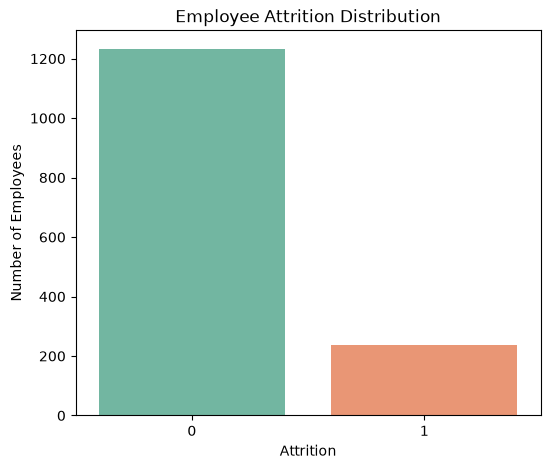

In [13]:
plt.figure(figsize=(6,5))

sns.countplot(
    x="Attrition",
    data=df,
    palette="Set2"
)

plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")

plt.show()

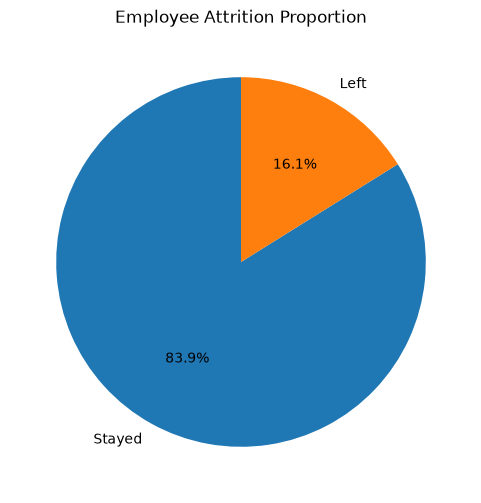

In [14]:
attrition_counts = df["Attrition"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    attrition_counts,
    labels=["Stayed", "Left"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Employee Attrition Proportion")

plt.show()

###  Business Insight

The overall attrition assessment provides a high-level view of employee turnover within the organization.

-  Most employees have remained with the organization, while a smaller proportion has left.
-  The calculated attrition rate serves as a baseline KPI for evaluating workforce stability.
-  This baseline will be used to compare attrition across departments, job roles, demographic groups, tenure levels, and workload factors in the subsequent analyses.

# 🏢 Department & Job Role Analysis

Department and job role analysis helps identify workforce segments experiencing the highest employee attrition. Understanding which business functions are most affected enables HR leaders to implement targeted retention strategies, improve employee engagement, and optimize workforce planning.

This section evaluates attrition across departments and job roles to identify organizational risk hotspots.

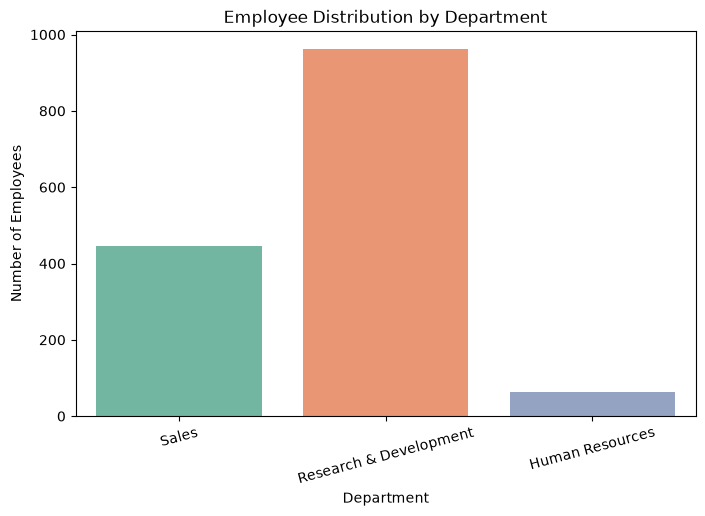

In [15]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Department",
    data=df,
    palette="Set2"
)

plt.title("Employee Distribution by Department")
plt.xlabel("Department")
plt.ylabel("Number of Employees")

plt.xticks(rotation=15)

plt.show()

###  Business Insight

This visualization shows the workforce distribution across different departments. Understanding employee distribution helps distinguish between departments with naturally larger workforces and those experiencing disproportionately high attrition.

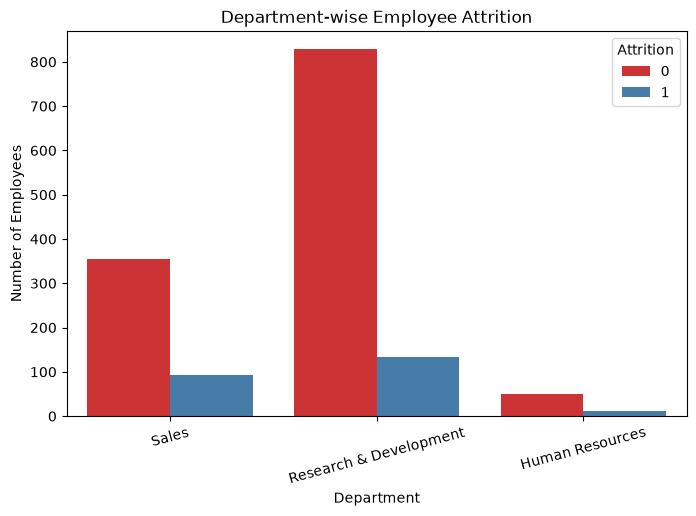

In [16]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Department",
    hue="Attrition",
    data=df,
    palette="Set1"
)

plt.title("Department-wise Employee Attrition")
plt.xlabel("Department")
plt.ylabel("Number of Employees")

plt.xticks(rotation=15)

plt.legend(title="Attrition")

plt.show()

###  Business Insight

Comparing attrition across departments helps identify functional areas facing the greatest employee turnover. Departments with consistently higher attrition may require focused retention initiatives, workload assessments, and employee engagement programs.

In [17]:
department_attrition = (
    df.groupby("Department")["Attrition"]
      .mean()
      .sort_values(ascending=False)
      *100
)

department_attrition

Department
Sales                     20.627803
Human Resources           19.047619
Research & Development    13.839750
Name: Attrition, dtype: float64

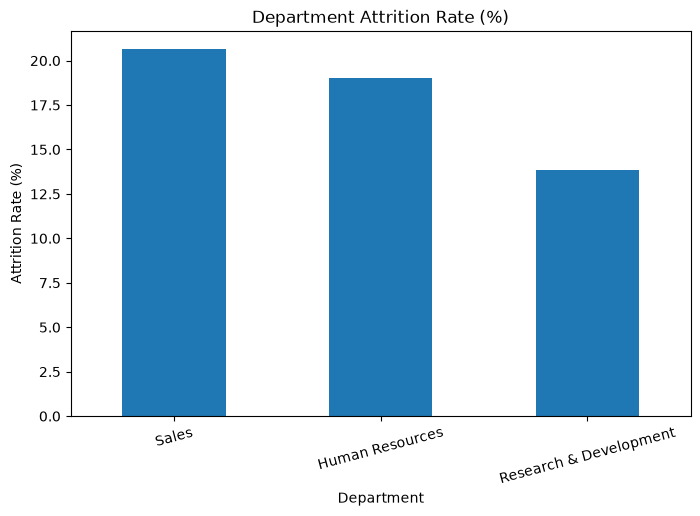

In [18]:
plt.figure(figsize=(8,5))

department_attrition.plot(kind="bar")

plt.title("Department Attrition Rate (%)")
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")

plt.xticks(rotation=15)

plt.show()

## Job Role Analysis

Job role analysis helps identify positions with the highest employee attrition. Understanding which roles experience greater turnover enables HR teams to design targeted retention strategies, improve employee engagement, and reduce recruitment costs.

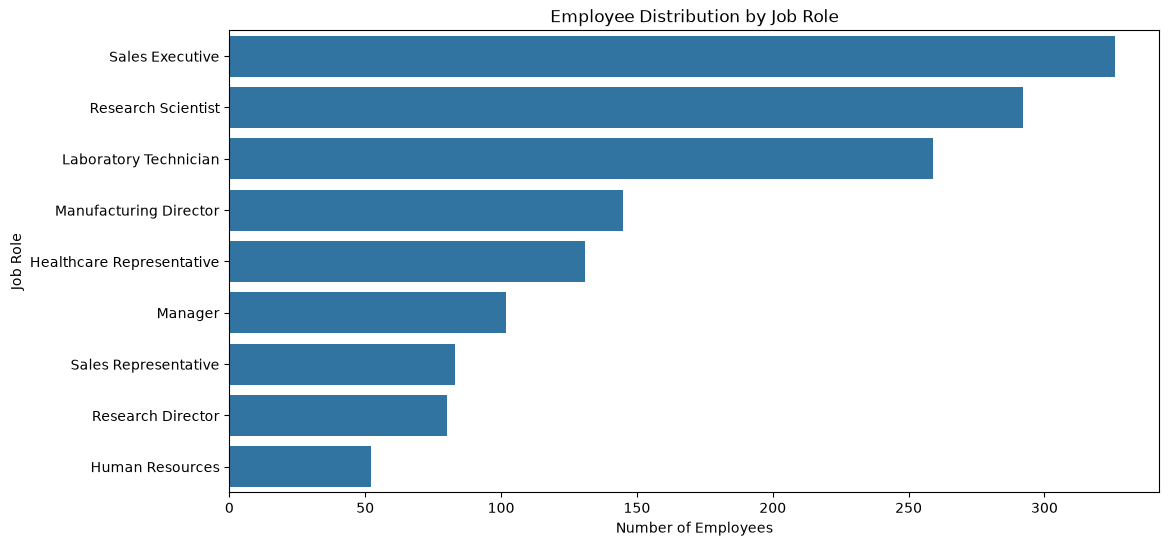

In [19]:
# Employee Distribution by Job Role

plt.figure(figsize=(12,6))

sns.countplot(
    y="JobRole",
    data=df,
    order=df["JobRole"].value_counts().index
)

plt.title("Employee Distribution by Job Role")
plt.xlabel("Number of Employees")
plt.ylabel("Job Role")

plt.show()

### Business Insight

This visualization shows the distribution of employees across different job roles. Roles with a larger workforce naturally contribute more employees to the organization, making it important to compare attrition rates rather than employee counts alone.

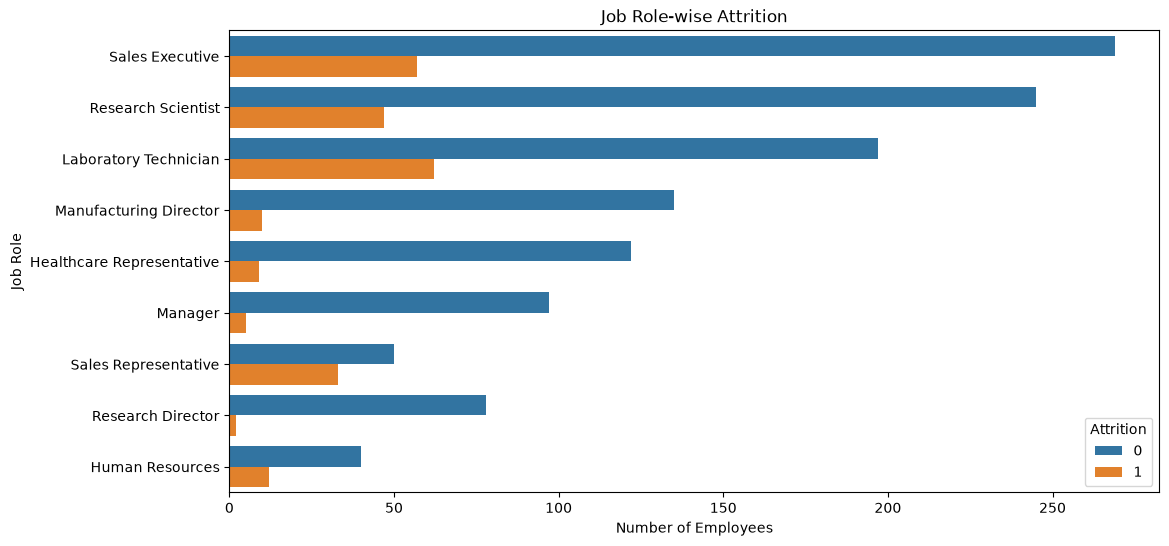

In [20]:
# Job Role-wise Attrition

plt.figure(figsize=(12,6))

sns.countplot(
    y="JobRole",
    hue="Attrition",
    data=df,
    order=df["JobRole"].value_counts().index
)

plt.title("Job Role-wise Attrition")
plt.xlabel("Number of Employees")
plt.ylabel("Job Role")

plt.legend(title="Attrition")

plt.show()

In [21]:
# Job Role Attrition Rate

jobrole_attrition = (
    df.groupby("JobRole")["Attrition"]
      .mean()
      .sort_values(ascending=False)
      *100
)

jobrole_attrition

JobRole
Sales Representative         39.759036
Laboratory Technician        23.938224
Human Resources              23.076923
Sales Executive              17.484663
Research Scientist           16.095890
Manufacturing Director        6.896552
Healthcare Representative     6.870229
Manager                       4.901961
Research Director             2.500000
Name: Attrition, dtype: float64

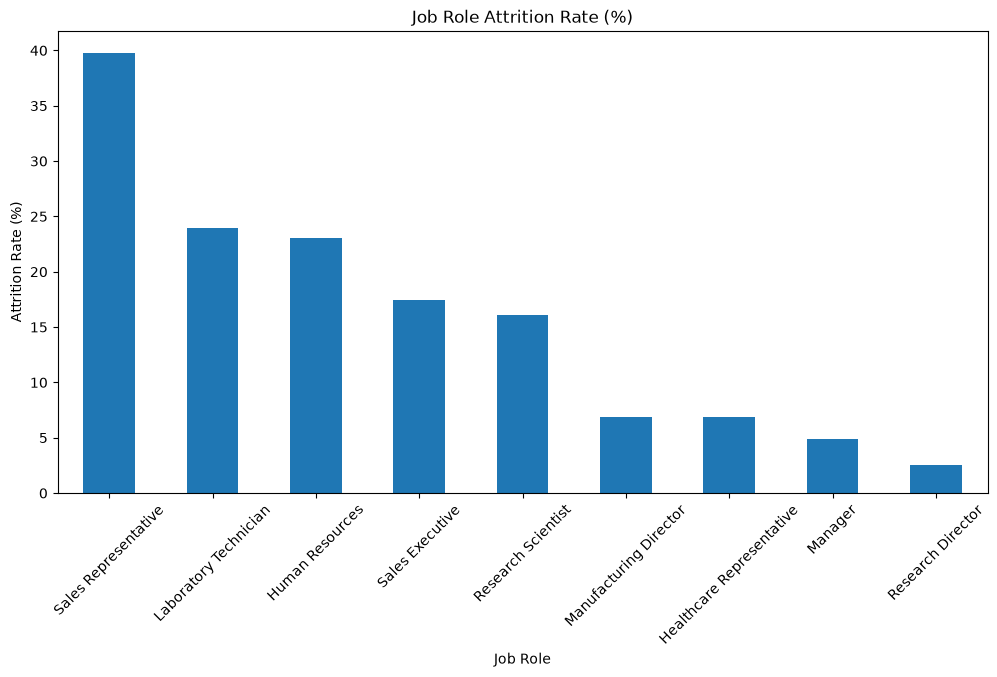

In [22]:
plt.figure(figsize=(12,6))

jobrole_attrition.plot(kind="bar")

plt.title("Job Role Attrition Rate (%)")
plt.xlabel("Job Role")
plt.ylabel("Attrition Rate (%)")

plt.xticks(rotation=45)

plt.show()

## Demographic Attrition Analysis

Employee attrition often varies across different demographic groups. This section examines attrition patterns based on age, gender, marital status, education level, and education field to identify workforce segments that may require targeted HR interventions.

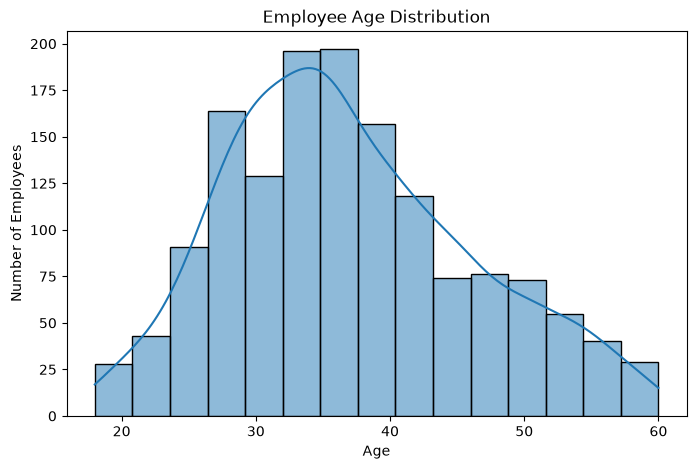

In [23]:
plt.figure(figsize=(8,5))

sns.histplot(df["Age"], bins=15, kde=True)

plt.title("Employee Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Employees")

plt.show()

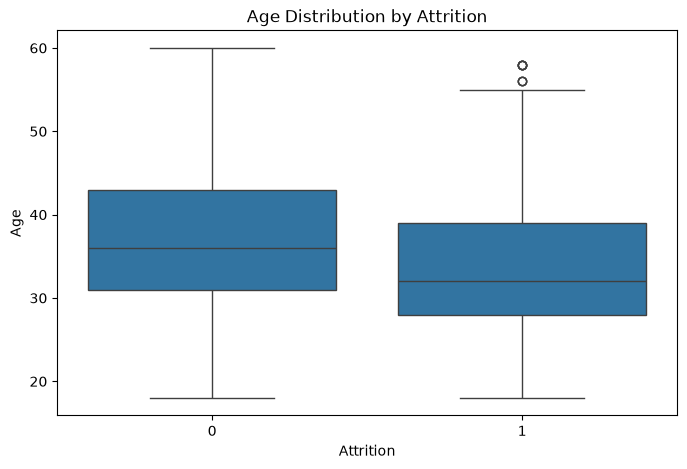

In [24]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Attrition",
    y="Age",
    data=df
)

plt.title("Age Distribution by Attrition")

plt.show()

### Business Insight

Age-based analysis helps determine whether employee turnover is concentrated within specific career stages. Understanding these patterns enables HR teams to design retention strategies tailored to employees at different stages of their professional journey.

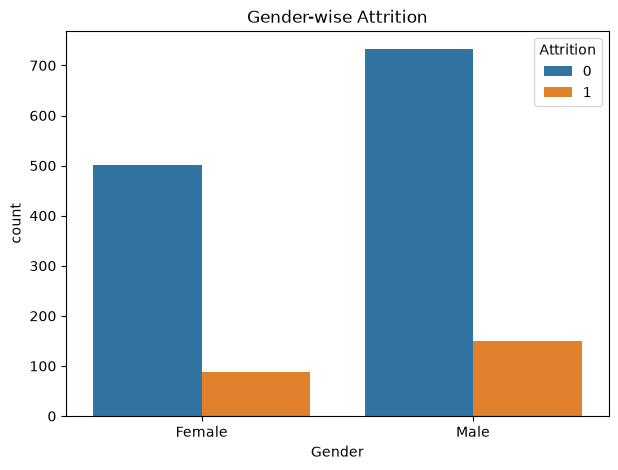

In [25]:
plt.figure(figsize=(7,5))

sns.countplot(
    x="Gender",
    hue="Attrition",
    data=df
)

plt.title("Gender-wise Attrition")

plt.show()

### Business Insight

Gender-wise attrition analysis evaluates whether employee turnover differs across the workforce. Any observed imbalance should be interpreted carefully and assessed alongside other workplace factors before making strategic HR decisions.

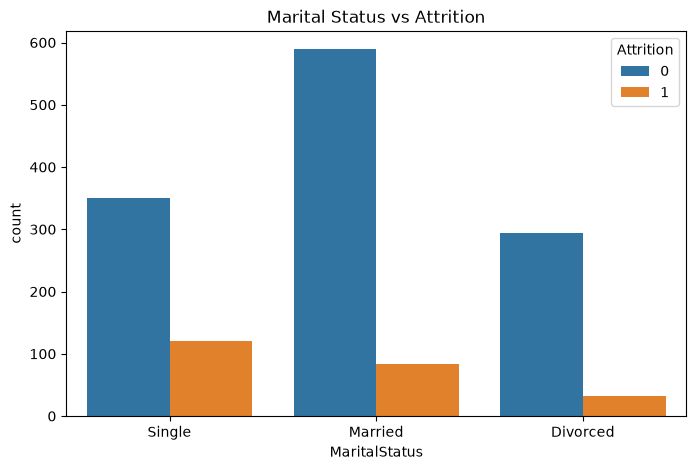

In [26]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="MaritalStatus",
    hue="Attrition",
    data=df
)

plt.title("Marital Status vs Attrition")

plt.show()

### Business Insight

Marital status may influence employee retention due to differences in personal responsibilities, career mobility, and work-life priorities. This analysis highlights whether particular employee groups experience higher attrition.

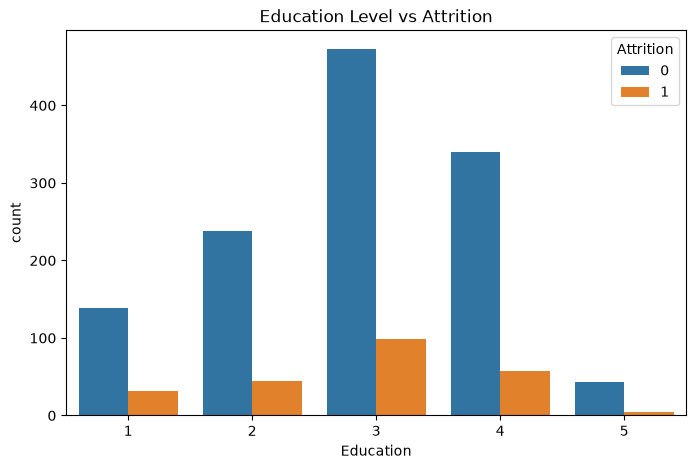

In [27]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Education",
    hue="Attrition",
    data=df
)

plt.title("Education Level vs Attrition")

plt.show()

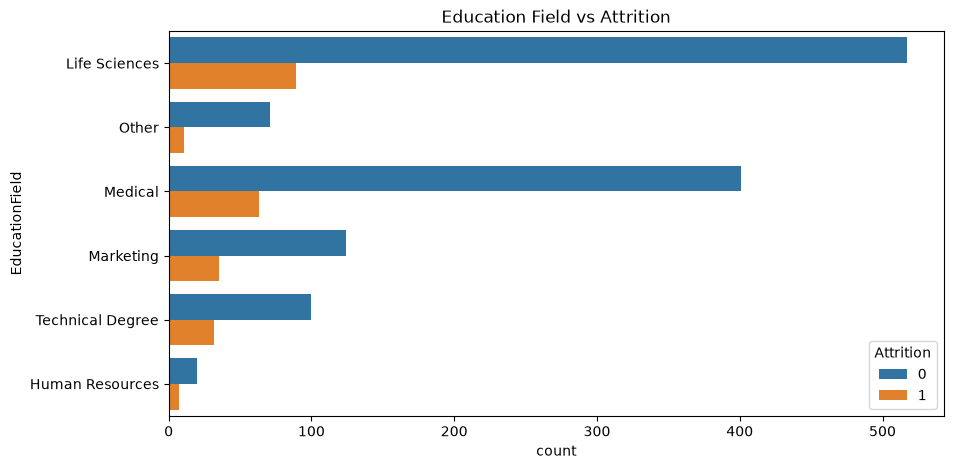

In [28]:
plt.figure(figsize=(10,5))

sns.countplot(
    y="EducationField",
    hue="Attrition",
    data=df
)

plt.title("Education Field vs Attrition")

plt.show()

## Tenure and Career Stage Analysis

Employee tenure and career progression are important factors influencing attrition. This analysis examines whether employees are more likely to leave during the early stages of employment or after experiencing limited career growth and promotion opportunities.

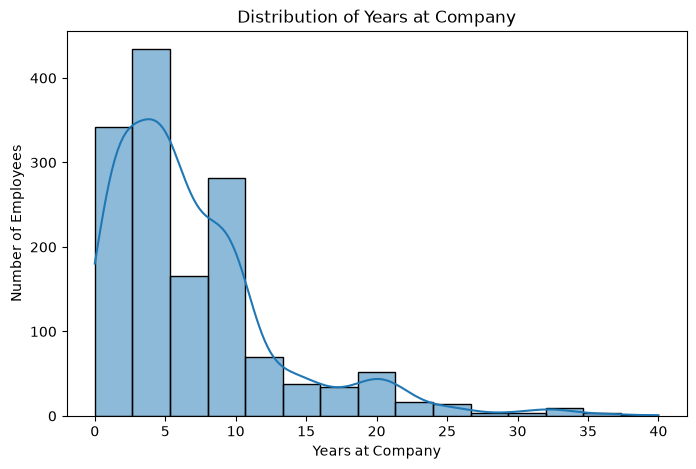

In [29]:
plt.figure(figsize=(8,5))

sns.histplot(df["YearsAtCompany"], bins=15, kde=True)

plt.title("Distribution of Years at Company")
plt.xlabel("Years at Company")
plt.ylabel("Number of Employees")

plt.show()

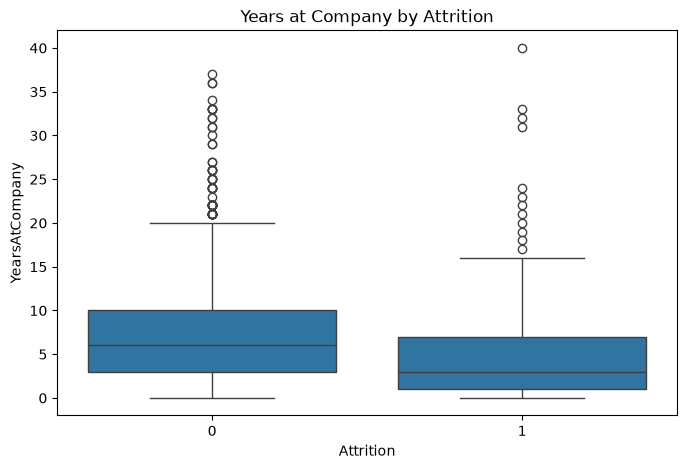

In [30]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Attrition",
    y="YearsAtCompany",
    data=df
)

plt.title("Years at Company by Attrition")

plt.show()

### Business Insight

Employees with shorter organizational tenure often exhibit higher attrition due to onboarding challenges, role expectations, or better external opportunities. Long-term employees generally demonstrate greater organizational commitment and stability.

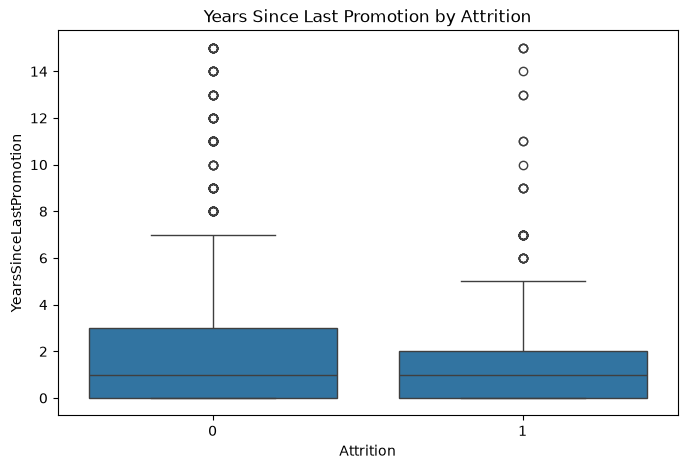

In [31]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Attrition",
    y="YearsSinceLastPromotion",
    data=df
)

plt.title("Years Since Last Promotion by Attrition")

plt.show()

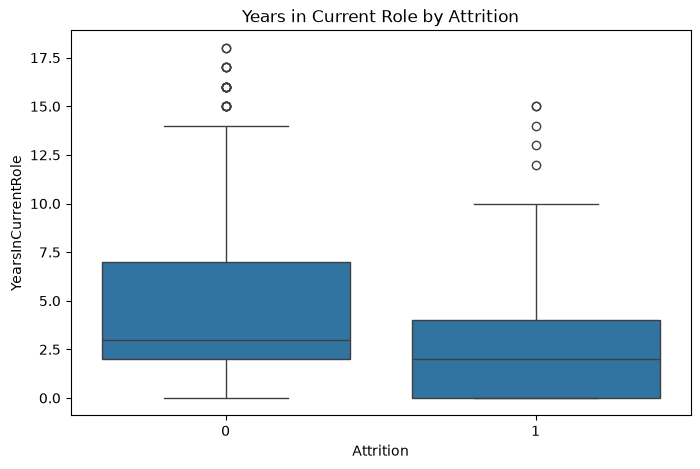

In [32]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Attrition",
    y="YearsInCurrentRole",
    data=df
)

plt.title("Years in Current Role by Attrition")

plt.show()

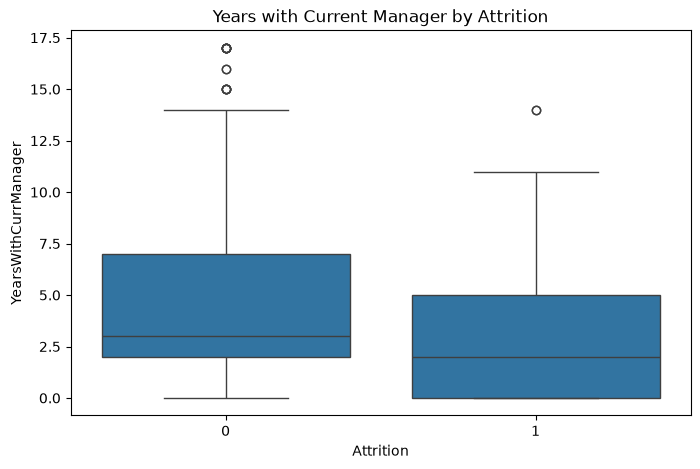

In [33]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Attrition",
    y="YearsWithCurrManager",
    data=df
)

plt.title("Years with Current Manager by Attrition")

plt.show()

## Career Stage Analysis

To better understand attrition across different career stages, employees are categorized based on their years at the company into Early Career, Mid Career, and Senior Career groups.

In [34]:
df["CareerStage"] = pd.cut(
    df["YearsAtCompany"],
    bins=[0, 3, 7, df["YearsAtCompany"].max()],
    labels=["Early Career", "Mid Career", "Senior Career"],
    include_lowest=True
)

df["CareerStage"].value_counts()

CareerStage
Senior Career    528
Mid Career       472
Early Career     470
Name: count, dtype: int64

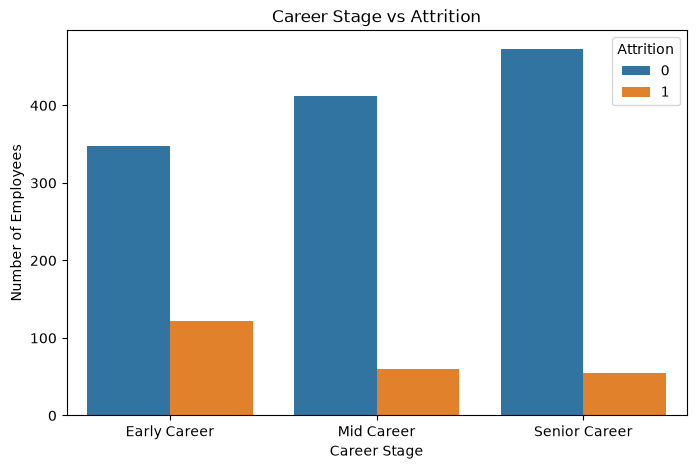

In [35]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="CareerStage",
    hue="Attrition",
    data=df
)

plt.title("Career Stage vs Attrition")

plt.xlabel("Career Stage")
plt.ylabel("Number of Employees")

plt.show()

### Business Insight

Career stage analysis highlights the phases of employment where attrition is most prominent. If attrition is concentrated among early-career employees, HR should focus on onboarding, mentoring, and employee engagement. Higher attrition among experienced employees may indicate career stagnation or limited growth opportunities.

# Key Performance Indicators (KPIs)

Key Performance Indicators (KPIs) provide measurable insights into workforce attrition and help HR leaders monitor employee retention across different organizational dimensions. These metrics establish a baseline for evaluating workforce stability and identifying areas that require strategic intervention.

In [36]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings("ignore")

In [37]:
df = pd.read_csv("Palo Alto Networks.csv")

In [38]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


In [39]:
overall_attrition_rate = (df["Attrition"].mean()) * 100

print(f"Overall Attrition Rate: {overall_attrition_rate:.2f}%")

Overall Attrition Rate: 16.12%


In [40]:
department_attrition_rate = (
    df.groupby("Department")["Attrition"]
      .mean()
      .sort_values(ascending=False) * 100
)

department_attrition_rate

Department
Sales                     20.627803
Human Resources           19.047619
Research & Development    13.839750
Name: Attrition, dtype: float64

In [41]:
jobrole_attrition_rate = (
    df.groupby("JobRole")["Attrition"]
      .mean()
      .sort_values(ascending=False) * 100
)

jobrole_attrition_rate

JobRole
Sales Representative         39.759036
Laboratory Technician        23.938224
Human Resources              23.076923
Sales Executive              17.484663
Research Scientist           16.095890
Manufacturing Director        6.896552
Healthcare Representative     6.870229
Manager                       4.901961
Research Director             2.500000
Name: Attrition, dtype: float64

In [42]:
early_tenure = df[df["YearsAtCompany"] <= 3]

early_attrition = early_tenure["Attrition"].mean() * 100

print(f"Early-Tenure Attrition Rate: {early_attrition:.2f}%")

Early-Tenure Attrition Rate: 25.96%


In [43]:
workload_attrition = (
    df.groupby("OverTime")["Attrition"]
      .mean() * 100
)

workload_attrition

OverTime
No     10.436433
Yes    30.528846
Name: Attrition, dtype: float64

In [44]:
kpi_summary = pd.DataFrame({
    "KPI": [
        "Overall Attrition Rate",
        "Early-Tenure Attrition Rate"
    ],
    "Value (%)": [
        round(overall_attrition_rate, 2),
        round(early_attrition, 2)
    ]
})

kpi_summary

,KPI,Value (%)
0,Overall Attrition Rate,16.12
1,Early-Tenure Attrition Rate,25.96


### Business Insight

The KPIs provide a concise overview of workforce stability and attrition patterns across the organization. Monitoring these indicators regularly enables HR teams to identify high-risk areas, evaluate the effectiveness of retention initiatives, and make evidence-based workforce planning decisions.

# Department and Job Role Heatmap

Heatmaps provide a visual representation of attrition intensity across different departments and job roles. They help identify workforce risk hotspots where employee turnover is comparatively higher, enabling HR teams to prioritize targeted retention strategies.

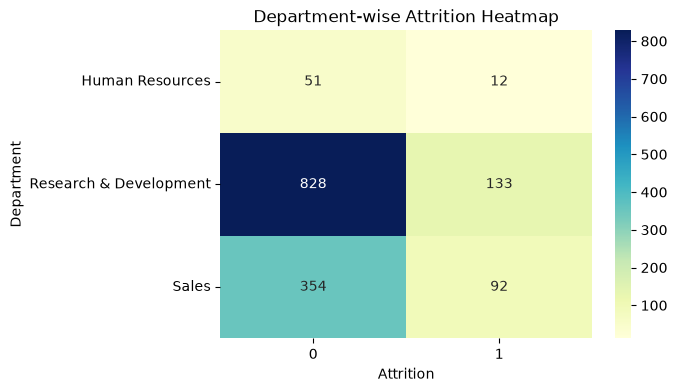

In [45]:
department_heatmap = pd.crosstab(
    df["Department"],
    df["Attrition"]
)

plt.figure(figsize=(6,4))

sns.heatmap(
    department_heatmap,
    annot=True,
    fmt="d",
    cmap="YlGnBu"
)

plt.title("Department-wise Attrition Heatmap")

plt.show()

### Business Insight

The heatmap highlights departments with comparatively higher employee exits. Departments showing greater attrition intensity should be prioritized for detailed workforce assessment and targeted retention initiatives.

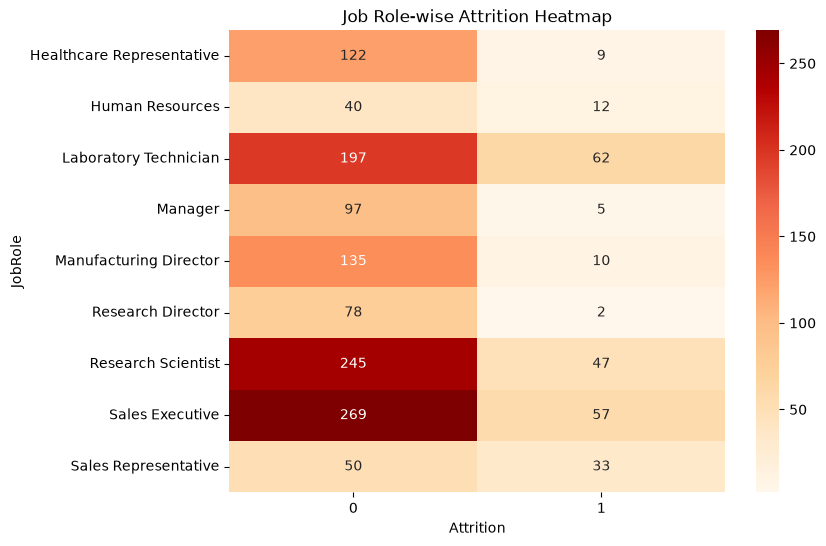

In [46]:
jobrole_heatmap = pd.crosstab(
    df["JobRole"],
    df["Attrition"]
)

plt.figure(figsize=(8,6))

sns.heatmap(
    jobrole_heatmap,
    annot=True,
    fmt="d",
    cmap="OrRd"
)

plt.title("Job Role-wise Attrition Heatmap")

plt.show()

### Business Insight

Job roles with higher attrition intensity indicate potential workforce instability. These roles should be reviewed to understand workload, compensation, career progression, and employee engagement challenges.

In [47]:
high_risk_departments = (
    df.groupby("Department")["Attrition"]
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

high_risk_departments.columns = ["Department", "Attrition Rate"]

high_risk_departments["Attrition Rate"] *= 100

high_risk_departments

,Department,Attrition Rate
0,Sales,20.627803
1,Human Resources,19.047619
2,Research & Development,13.839750


In [48]:
high_risk_roles = (
    df.groupby("JobRole")["Attrition"]
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

high_risk_roles.columns = ["Job Role", "Attrition Rate"]

high_risk_roles["Attrition Rate"] *= 100

high_risk_roles

,Job Role,Attrition Rate
0,Sales Representative,39.759036
1,Laboratory Technician,23.938224
2,Human Resources,23.076923
3,Sales Executive,17.484663
4,Research Scientist,16.095890
5,Manufacturing Director,6.896552
6,Healthcare Representative,6.870229
7,Manager,4.901961
8,Research Director,2.500000


# Predictive Analytics using Machine Learning

In addition to descriptive analysis, a predictive model is developed to identify employees who are at risk of leaving the organization. A Random Forest Classifier is selected due to its robustness, ability to handle mixed data types, and effectiveness in classification problems.

The model predicts employee attrition based on demographic, job-related, compensation, workload, and career progression factors.

In [49]:
df_ml = df.copy()

## Data Preprocessing

Before training the machine learning model, categorical variables must be converted into numerical values. Label Encoding is applied to transform categorical features while preserving all available information for model training.

In [50]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for column in df_ml.select_dtypes(include="object").columns:
    df_ml[column] = le.fit_transform(df_ml[column])

df_ml.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,2,1102,2,1,2,1,2,0,...,3,1,0,8,0,1,6,4,0,5
1,49,0,1,279,1,8,1,1,3,1,...,4,4,1,10,3,3,10,7,1,7
2,37,1,2,1373,1,2,2,4,4,1,...,3,2,0,7,3,3,0,0,0,0
3,33,0,1,1392,1,3,4,1,4,0,...,3,3,0,8,3,3,8,7,3,0
4,27,0,2,591,1,2,1,3,1,1,...,3,4,1,6,3,3,2,2,2,2


## Feature Selection

The target variable for this project is **Attrition**, while all remaining variables are used as input features to train the predictive model.

In [51]:
X = df_ml.drop("Attrition", axis=1)

y = df_ml["Attrition"]

## Train-Test Split

The dataset is divided into training and testing subsets. The training dataset is used to build the model, while the testing dataset evaluates its predictive performance on unseen employee records.

In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

## Random Forest Model

A Random Forest Classifier is trained to predict employee attrition. Random Forest combines multiple decision trees to improve prediction accuracy and reduce overfitting, making it well-suited for HR analytics classification tasks.

In [53]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [54]:
y_pred = rf_model.predict(X_test)

## Model Evaluation

The trained Random Forest model is evaluated using multiple performance metrics to measure its effectiveness in predicting employee attrition. Accuracy, confusion matrix, and classification report provide insights into the model's predictive capability.

In [55]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.2%}")

Model Accuracy: 88.10%


In [56]:
cm = confusion_matrix(y_test, y_pred)

cm

array([[254,   1],
       [ 34,   5]])

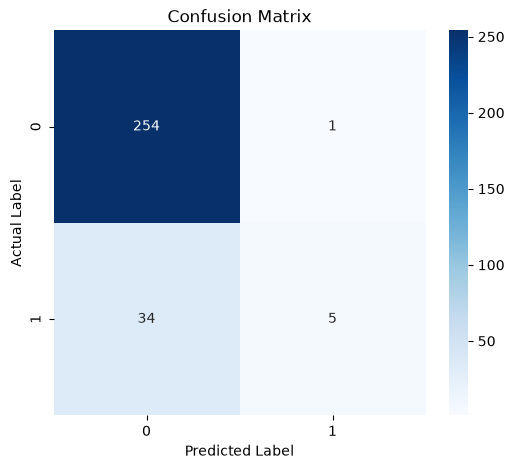

In [57]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

In [58]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      1.00      0.94       255
           1       0.83      0.13      0.22        39

    accuracy                           0.88       294
   macro avg       0.86      0.56      0.58       294
weighted avg       0.88      0.88      0.84       294



### Business Insight

The evaluation metrics indicate how effectively the Random Forest model predicts employee attrition. A higher accuracy and balanced classification performance suggest that the model can support HR teams in identifying employees who may be at risk of leaving, enabling proactive retention planning.

## Feature Importance Analysis

Feature importance identifies the variables that contribute most to the prediction of employee attrition. Understanding these influential factors enables HR leaders to focus on the workforce characteristics that have the greatest impact on employee retention.

In [59]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
15,MonthlyIncome,0.078212
18,OverTime,0.066669
0,Age,0.061569
2,DailyRate,0.054087
23,TotalWorkingYears,0.052491
16,MonthlyRate,0.048373
9,HourlyRate,0.047369
4,DistanceFromHome,0.045999
26,YearsAtCompany,0.041347
17,NumCompaniesWorked,0.037951


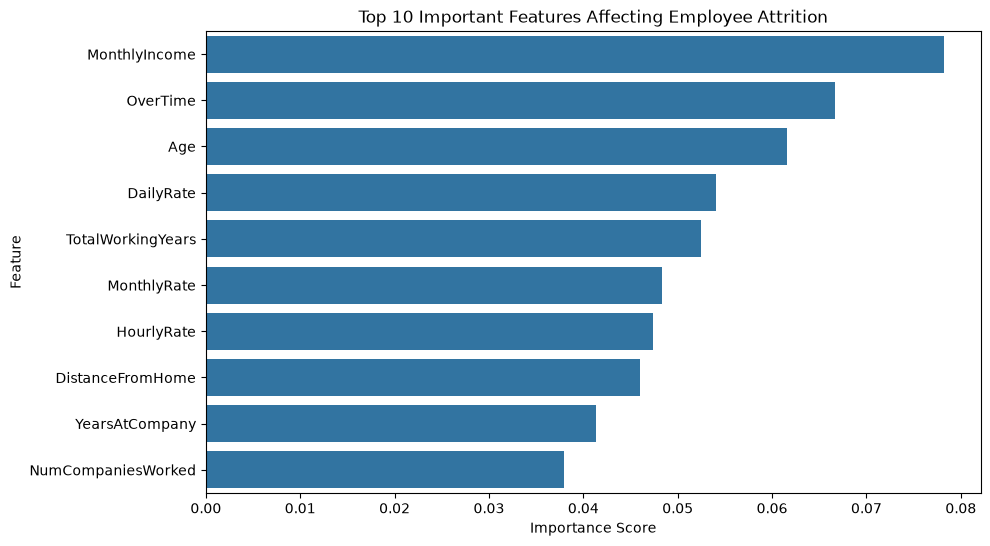

In [60]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features Affecting Employee Attrition")

plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.show()

### Business Insight

The feature importance analysis highlights the key factors influencing employee attrition. Variables with higher importance scores have a stronger impact on the model's predictions and should be prioritized when designing employee retention strategies and workforce planning initiatives.

# Strategic HR Recommendations

Based on the findings from the exploratory data analysis and predictive modeling, the following recommendations are proposed to reduce employee attrition and strengthen workforce retention at Palo Alto Networks.

### Recommendation 1: Strengthen Early Employee Engagement

The analysis indicates that employees in the early stages of their careers are more likely to leave the organization. Structured onboarding programs, mentoring initiatives, and regular feedback sessions can improve employee engagement and retention.

### Recommendation 2: Monitor High-Risk Departments and Job Roles

Departments and job roles with higher attrition rates should receive targeted retention strategies. HR teams should regularly review employee satisfaction, workload, and career development opportunities within these groups.

### Recommendation 3: Improve Work-Life Balance

Workload-related factors such as overtime and frequent business travel should be monitored carefully. Promoting flexible work arrangements and balanced workloads can improve employee well-being and reduce turnover.

### Recommendation 4: Enhance Career Development

Employees who experience limited career progression or delayed promotions may become disengaged. Providing clear career paths, learning opportunities, and internal mobility programs can improve long-term retention.

### Recommendation 5: Adopt Data-Driven HR Decision Making

HR leaders should continuously monitor attrition KPIs using analytics dashboards and predictive models to identify workforce risks early and support evidence-based decision-making.

# Executive Summary

This project analyzed workforce attrition at Palo Alto Networks using HR Analytics techniques. The analysis examined employee turnover across departments, job roles, demographic groups, career stages, workload factors, and workplace satisfaction indicators.

Exploratory Data Analysis identified workforce segments with comparatively higher attrition and highlighted the influence of factors such as overtime, business travel, tenure, and career progression. A Random Forest Classifier was developed to predict employee attrition, providing a data-driven approach for identifying employees who may be at risk of leaving the organization.

The findings demonstrate how HR Analytics can support workforce planning, improve employee retention strategies, and enable proactive organizational decision-making.

# Conclusion

Employee attrition is influenced by multiple organizational and employee-related factors rather than a single variable. This project demonstrated the application of HR Analytics to identify attrition patterns, evaluate workforce risk hotspots, and build a predictive machine learning model for employee attrition.

The insights generated from this analysis can help HR leaders prioritize retention initiatives, improve employee engagement, strengthen career development programs, and enhance workforce planning. By combining exploratory data analysis with predictive analytics, organizations can make more informed decisions and create sustainable employee retention strategies.